# Visualisasi Data dengan Matplotlib dan Seaborn {#sec-modul-5}

::: {.callout-important title="Sub-CPMK Pertemuan Ini"}
Mahasiswa mampu merumuskan visualisasi data perkotaan yang informatif menggunakan Matplotlib dan Seaborn, memilih jenis grafik yang tepat sesuai karakteristik data, menerapkan estetika grafik, dan menyusun interpretasi naratif atas visualisasi tersebut.
:::

## Pendahuluan

[\<masukkan narasi yang menceritakan 'big why' mempelajari visualisasi data dengan Matplotlib dan Seaborn di sini\>]{.teks-placeholder style="color: #8a8a8a;"}

## Gambaran Umum Kasus

Sebagai peserta studio perencanaan wilayah dan kota, Anda tentu akrab dengan laporan kompilasi data. Angka-angka di tabel profil kelurahan Bandar Lampung yang kita olah sebelumnya sangat sulit dibaca secara langsung oleh pengambil keputusan jika hanya disajikan dalam bentuk tabel baris-kolom yang kaku. Di sinilah visualisasi data berperan penting. Grafik yang dirancang dengan baik tidak hanya mempercepat pemahaman, tetapi juga meminimalisir kesalahan interpretasi kebijakan pembangunan kota.

Bayangkan visualisasi data sebagai proses menggambar grafik presentasi untuk sidang studio perencanaan. Jika grafik kita tidak memiliki judul yang jelas, label sumbunya terpotong, warnanya saling bertabrakan, atau legendanya hilang, asisten studio atau dosen pembimbing pasti akan langsung memberikan coretan revisi berwarna merah pada kertas gambar kita. Di modul ini, kita akan mempelajari prinsip dasar visualisasi yang baik dan mempraktikkannya untuk memvisualisasikan profil fasilitas pendidikan dan kepadatan penduduk Kota Bandar Lampung menggunakan pustaka Matplotlib dan Seaborn.

## Instruksi

Buat notebook baru `modul/modul-05.ipynb` di direktori proyek Anda, sambungkan ke *kernel* `analitika-perkotaan`, dan kerjakan seluruh instruksi di dalamnya.

### Prinsip Visualisasi: Memilih Grafik Sesuai Pertanyaan Perencanaan

Sebelum mulai memprogram, pahami terlebih dahulu kerangka pikir visualisasi data yang dirancang untuk kebutuhan analisis dan presentasi laporan studio:

- **Tiga Prinsip Schwabish**:
  - *Tunjukkan Data*: Pastikan perhatian pembaca tertuju langsung pada informasi utama grafik.
  - *Kurangi Kekacauan (Reduce Clutter)*: Bersihkan elemen dekoratif non-data yang mengganggu kognisi (seperti efek 3D, bayangan, atau garis kisi-kisi latar belakang yang terlalu tebal).
  - *Integrasikan Teks*: Tempatkan label atau legenda sedekat mungkin dengan data untuk mengurangi beban kognitif pembaca.

- **Taksonomi Data**:
  - *Kuantitatif (Numerik)*: Data yang dapat dihitung atau diukur (misalnya kepadatan penduduk atau jumlah sekolah). Data ini bisa berupa *diskrit* (bulat, seperti jumlah sekolah) atau *kontinu* (desimal, seperti luas wilayah).
  - *Kategorikal (Kualitatif)*: Data pengelompokkan (seperti nama kecamatan atau jenis topografi). Data ini bisa berupa *nominal* (tanpa urutan, seperti jenis lapangan usaha) atau *ordinal* (memiliki tingkatan/urutan, seperti tingkat kepuasan layanan).
  - **Analisis "So What?"**: Jangan pernah menggunakan grafik garis (*line chart*) bersambung untuk data yang bersifat diskrit antarkategori (misalnya jumlah sekolah per kelurahan). Garis yang terhubung secara implisit menunjukkan adanya nilai antara di sepanjang garis tersebut, padahal di lapangan tidak ada nilai transisi antar-kelurahan. Ini adalah kesalahan visualisasi yang fatal.

- **Pohon Keputusan Pemilihan Grafik**:
  Berikut adalah panduan sederhana memilih grafik yang sesuai dengan tujuan analisis Anda:

```{mermaid}
%%| fig-width: 6
flowchart LR
    A["Tujuan Visualisasi"] --> B{"Pilih Berdasarkan Kebutuhan"}
    B --> C["Perbandingan"] --> C1["Diagram Batang (Item)<br>Grafik Garis (Waktu)"]
    B --> D["Komposisi"] --> D1["Pie Chart (Sederhana)<br>Stacked Bar (Kompleks)"]
    B --> E["Distribusi"] --> E1["Histogram (Frekuensi)<br>Box Plot (Statistik)"]
    B --> F["Hubungan"] --> F1["Scatter Plot (2 Variabel)"]
```

*Catatan*: Diagram di atas membantu kita mencocokkan pertanyaan perencanaan dengan jenis visual yang tepat secara instan.

### Persiapan Data dan Impor Pustaka

Seperti pada modul-modul sebelumnya, kita akan menggunakan basis data relasional SQLite `bdl.sqlite` yang berada di folder dataset sebagai sumber data utama. Impor pustaka yang diperlukan (`sqlite3`, `pandas`, `matplotlib.pyplot`, dan `seaborn`), buka koneksi basis data, lalu muat data gabungan kelurahan dan kecamatan menggunakan `LEFT JOIN` ke dalam DataFrame Pandas:

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Buka koneksi basis data
path_db = "../dataset-ganjil-2026-2027/bdl.sqlite"
koneksi = sqlite3.connect(path_db)

# Ambil seluruh data kelurahan beserta nama kecamatan induknya
kueri = """
SELECT 
    kel.*, 
    kec.nama_kec 
FROM 
    kelurahan kel
LEFT JOIN 
    kecamatan kec ON kel.kode_kec = kec.kode_kec
"""
df = pd.read_sql(kueri, koneksi)
print(df.shape)

(126, 34)


### Diagram Batang: Membandingkan Fasilitas Antar-Kecamatan

Pertanyaan pertama kita: *Kecamatan mana yang memiliki jumlah fasilitas taman kanak-kanak (TK) terbanyak?*

Untuk menjawab perbandingan kuantitas antar-item kategorikal (nama kecamatan), grafik batang adalah pilihan paling tepat. Kita perlu menghitung total TK (`jml_tk_negeri + jml_tk_swasta`) untuk setiap kelurahan terlebih dahulu, lalu mengelompokkannya (*group by*) berdasarkan nama kecamatan, dan mengurutkannya dari yang terbanyak.

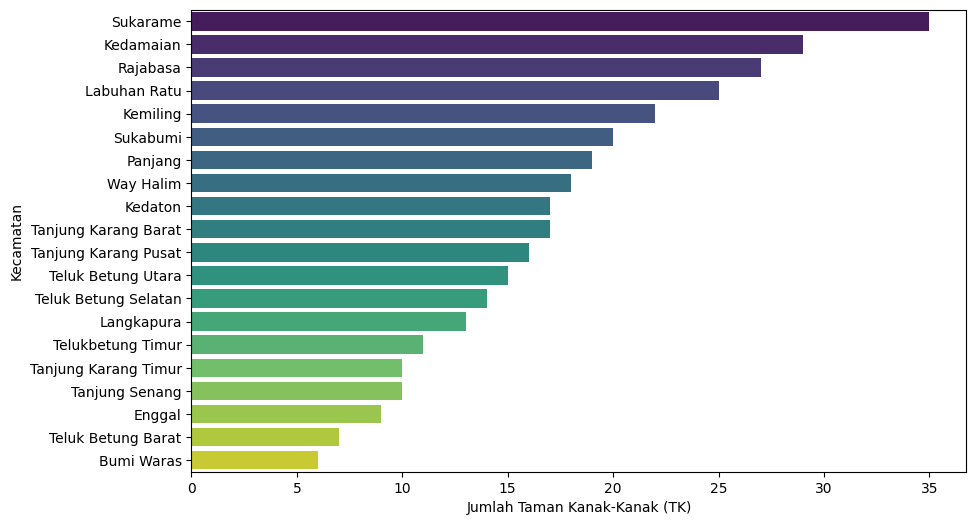

In [2]:
# Hitung total TK di setiap kelurahan
df["total_tk"] = df["jml_tk_negeri"] + df["jml_tk_swasta"]

# Agregasikan total TK per kecamatan
tk_per_kec = df.groupby("nama_kec")["total_tk"].sum().reset_index()
tk_per_kec = tk_per_kec.sort_values(by="total_tk", ascending=False)

# Mulai membuat plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tk_per_kec,
    x="total_tk",
    y="nama_kec",
    hue="nama_kec",
    palette="viridis",
    legend=False
)
plt.xlabel("Jumlah Taman Kanak-Kanak (TK)")
plt.ylabel("Kecamatan")
plt.show()

::: {.callout-warning title="Penting!"}
### Etika dan Batas Sumbu Y pada Grafik Batang {.unnumbered .unlisted}

Grafik batang menggunakan panjang visual untuk membandingkan kuantitas. Karena itu, sumbu kuantitas (dalam diagram batang horizontal di atas adalah sumbu X, sedangkan pada diagram batang vertikal adalah sumbu Y) **wajib dimulai dari nol**. Jika Anda memotong sumbu kuantitas di atas nol, perbedaan tinggi batang akan terlihat jauh lebih dramatis daripada aslinya, sehingga membohongi pembaca secara visual. Hal ini dikategorikan sebagai distorsi data yang tidak etis.

Namun, untuk keperluan pembuktian teknis tertentu di mana Anda ingin mengatur batas sumbu secara manual (misalnya ingin menyoroti perbedaan yang sangat tipis pada grafik lain, atau memotong nilai dasar secara sengaja), Anda bisa menggunakan perintah limit pada sumbu:
- Jika diagram batang vertikal atau sumbu Y: `plt.ylim(bottom=nilai_minimum)` atau `ax.set_ylim(bottom=nilai_minimum)`.
- Jika diagram batang horizontal atau sumbu X: `plt.xlim(left=nilai_minimum)` atau `ax.set_xlim(left=nilai_minimum)`.

Terapkan teknik ini dengan sangat hati-hati, sertakan label nilai angka yang jelas di atas batang, dan beri catatan penjelas pada grafik Anda agar tidak menimbulkan salah tafsir.
:::

### Scatter Plot: Menelusuri Hubungan Kepadatan dan Fasilitas

Pertanyaan kedua kita: *Apakah kelurahan yang semakin padat penduduknya memiliki jumlah fasilitas TK yang lebih banyak?*

Ini adalah pertanyaan hubungan (*relationship*) antara dua variabel numerik (`kepadatan_pddk` dan `total_tk`). Sesuai pohon keputusan, grafik sebar (*scatter plot*) adalah pilihan ideal untuk melihat sebaran titik amatan ini.

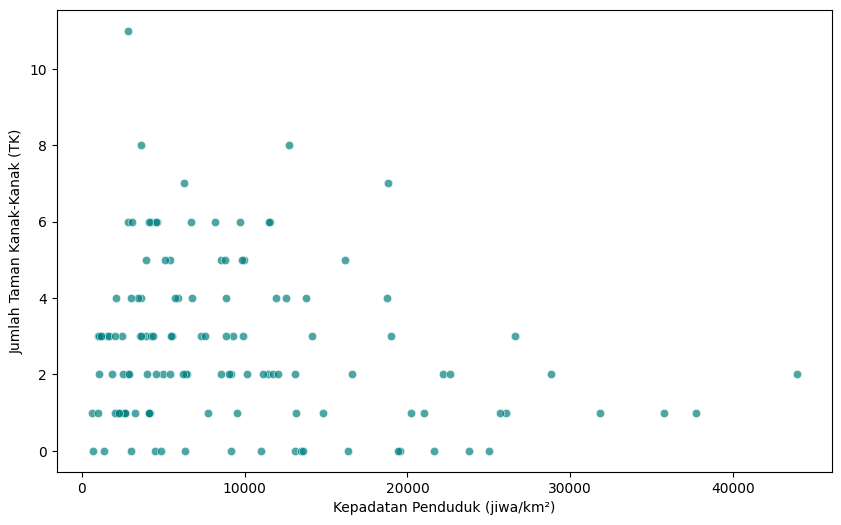

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="kepadatan_pddk", y="total_tk", alpha=0.7, color="teal")
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Jumlah Taman Kanak-Kanak (TK)")
plt.show()

::: {.callout-tip title="Pengetahuan VS Code"}
### Fitur Interactive Plot Viewer {.unnumbered .unlisted}

Ketika Anda menggunakan Visual Studio Code untuk menjalankan Jupyter Notebook, arahkan kursor mouse ke bagian grafik yang baru saja ter-render. Di sudut kanan atas gambar, VS Code secara otomatis menyediakan tombol ikon untuk mengaktifkan *Plot Viewer*. Dengan alat ini, Anda bisa memperbesar (*zoom*), menggeser area (*pan*), atau menyimpan file gambar secara langsung tanpa perlu mengetik kode tambahan di editor Anda.
:::

### Histogram, Density Plot, dan Box Plot: Membaca Distribusi Kepadatan Penduduk Kota

Pertanyaan ketiga kita: *Bagaimana sebaran kepadatan penduduk antarkelurahan di Bandar Lampung? Apakah mayoritas kelurahan memiliki kepadatan penduduk yang seragam, atau ada ketimpangan sebaran?*

Ini adalah pertanyaan seputar distribusi (*distribution*). Kita akan memadukan histogram (mengelompokkan nilai ke dalam tabung/bin) dengan kurva estimasi kepadatan kernel (*Kernel Density Estimate* atau KDE) untuk memvisualisasikan bentuk sebarannya:

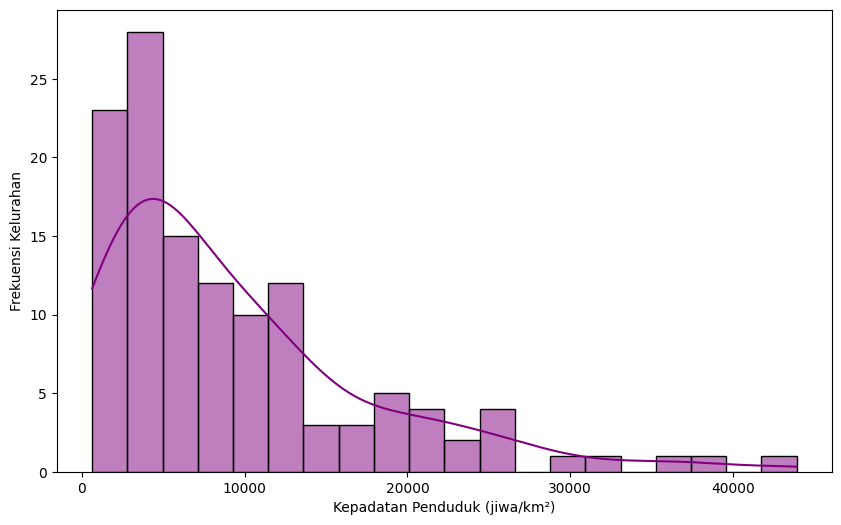

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df["kepadatan_pddk"], kde=True, bins=20, color="purple")
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Frekuensi Kelurahan")
plt.show()

Selain histogram, pohon keputusan kita juga menyebut *box plot* sebagai grafik distribusi. Jika histogram menunjukkan bentuk sebaran, *box plot* meringkas sebaran itu menjadi lima angka statistik: nilai minimum, kuartil pertama, median, kuartil ketiga, dan nilai maksimum — sementara titik-titik di luar "pagar" adalah *outlier* yang sudah kita kenali di Modul 4. Keunggulan utamanya: *box plot* mudah dijajarkan antarkelompok kategorikal. Mari bandingkan sebaran kepadatan penduduk antarjenis topografi wilayah:

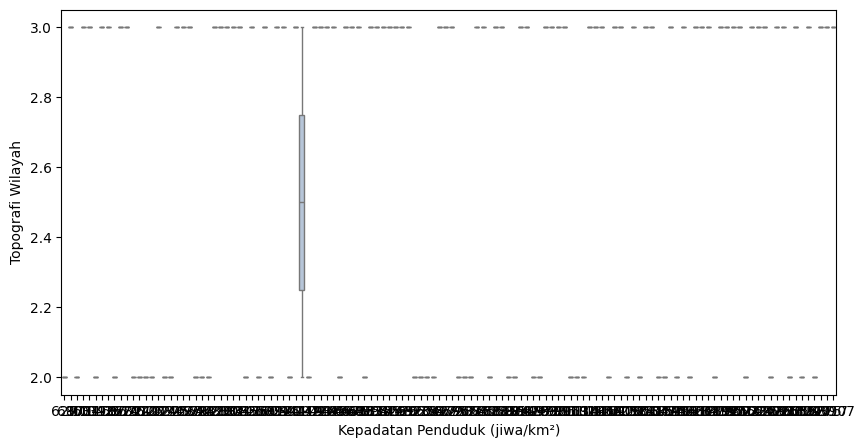

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="kepadatan_pddk", y="topo", color="lightsteelblue")
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Topografi Wilayah")
plt.show()

### Estetika Visual: Menambahkan Judul, Label, Legenda, dan Warna Harmonis

Grafik-grafik di atas secara teknis sudah benar, tetapi tampilannya masih sangat dasar. Untuk presentasi studio yang bernilai profesional, kita wajib menerapkan estetika visual: menambahkan judul yang deskriptif, memperjelas label sumbu, merapikan legenda, dan memoles tampilannya.

Kita akan menyusun opsi pengaturan font dan warna di dalam variabel dictionary, lalu membongkarnya (*unpacking*) ke dalam perintah visualisasi untuk menjaga efisiensi penulisan kode:

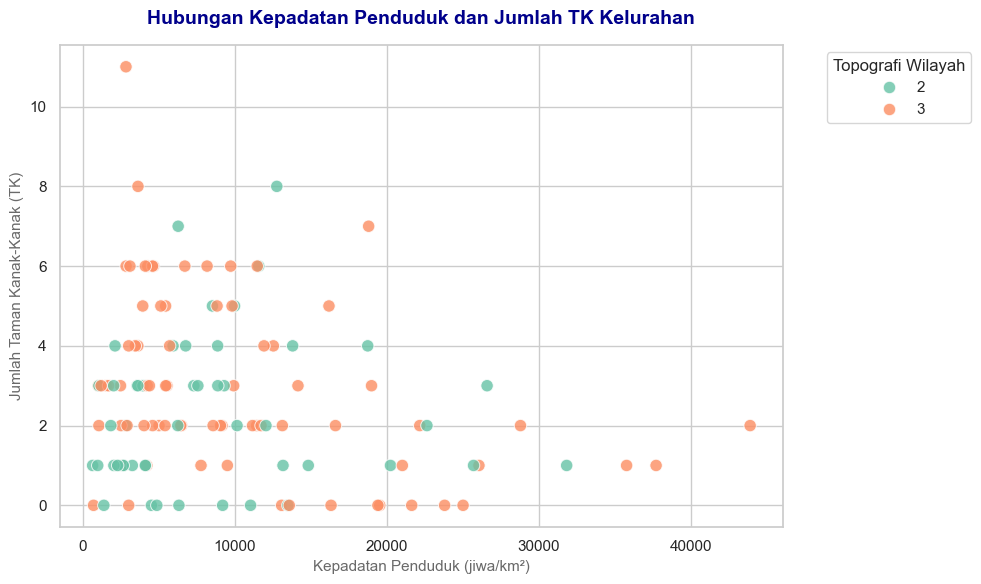

In [6]:
# Mengatur gaya estetika Seaborn
sns.set_theme(style="whitegrid")

# Membuat dictionary berisi opsi teks judul agar seragam dan rapi
opsi_judul = {
    "fontsize": 14, 
    "fontweight": "bold", 
    "color": "darkblue",
    "pad": 15
}
opsi_label = {
    "fontsize": 11,
    "color": "dimgray"
}

# Memulai penggambaran grafik yang sudah dipoles
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="kepadatan_pddk", 
    y="total_tk", 
    hue="topo", 
    palette="Set2", 
    alpha=0.8,
    s=80
)

# Menerapkan dictionary opsi label ke elemen teks
plt.title("Hubungan Kepadatan Penduduk dan Jumlah TK Kelurahan", **opsi_judul)
plt.xlabel("Kepadatan Penduduk (jiwa/km²)", **opsi_label)
plt.ylabel("Jumlah Taman Kanak-Kanak (TK)", **opsi_label)
plt.legend(title="Topografi Wilayah", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

::: {.callout-note title="Konsep Python"}
### Dictionary dan Dictionary Unpacking (`**`) {.unnumbered .unlisted}

**Dictionary** adalah tipe data koleksi pada Python yang menyimpan pasangan kunci (*key*) dan nilai (*value*). Berbeda dengan *list* yang diakses menggunakan indeks angka (0, 1, ...), kamus ini diakses menggunakan kunci bertipe string atau tipe data tak-berubah lainnya.

Contoh pendefinisian kamus:
```python
opsi_judul = {"fontsize": 14, "color": "darkblue"}
```
Untuk menggunakan nilai di dalamnya, kita bisa memanggil kuncinya: `opsi_judul["color"]`.

**Dictionary Unpacking (`**`)** adalah operator pembongkaran. Ketika kita memanggil fungsi dan meletakkan tanda bintang ganda (`**`) sebelum nama variabel dictionary, Python akan secara otomatis membongkar seluruh pasangan kunci-nilai tersebut dan meneruskannya sebagai argumen kata kunci (*keyword arguments*) ke dalam fungsi tersebut.

Jadi, penulisan:
```python
plt.title("Judul", **opsi_judul)
```
Secara instan diterjemahkan oleh interpreter Python menjadi:
```python
plt.title("Judul", fontsize=14, color="darkblue")
```
Teknik ini sangat berguna untuk membuat templat gaya teks yang bersih, konsisten, dan mudah diperbarui di satu baris tunggal, sehingga Anda tidak perlu mengetik argumen dekoratif berulang-ulang di setiap grafik.
:::

::: {.callout-note title="Pengetahuan Komputer"}
### Konsep DPI (Dots Per Inch) untuk Ekspor Grafik {.unnumbered .unlisted}

Saat Anda menyusun laporan studio perencanaan, gambar visualisasi tidak cukup hanya tampil di layar komputer. Grafik tersebut harus diekspor sebagai file gambar statis untuk dimasukkan ke laporan akhir (Word/PDF) atau poster presentasi.

Gunakan fungsi `plt.savefig()` untuk menyimpan grafik. Secara default, resolusi ekspor berkisar pada 72-96 DPI (*Dots Per Inch*), yang akan terlihat buram atau pecah ketika dicetak di atas kertas fisik. Untuk publikasi cetak yang tajam, biasakan mengekspor dengan resolusi minimal **300 DPI**:
```python
# Menyimpan file grafik dengan ketajaman tinggi untuk cetakan
plt.savefig("hubungan_kepadatan_tk.png", dpi=300, bbox_inches="tight")
```
Argumen `bbox_inches="tight"` memastikan agar tidak ada teks label atau legenda di pinggir grafik yang terpotong saat file gambar disimpan.
:::

### Storytelling: Menuliskan Interpretasi Naratif di Bawah Grafik

Membuat grafik hanyalah separuh tugas dari seorang analis perkotaan. Tugas terpenting berikutnya adalah menuliskan cerita di balik data (*storytelling*) dalam bentuk narasi pendek yang diletakkan tepat di bawah grafik. Narasi visual yang baik dalam studio perencanaan minimal menjawab tiga pertanyaan dasar:
1. *Pola umum apa yang terlihat secara jelas pada grafik?*
2. *Apakah ada anomali atau titik ekstrem yang menarik perhatian?*
3. *Apa rekomendasi awal atau implikasi kebijakan tata ruang dari temuan visual tersebut?*

Mari kita buat interpretasi singkat dari grafik hubungan kepadatan dan jumlah TK di atas:

> **Interpretasi Grafik:**
> Grafik sebar di atas menunjukkan bahwa hubungan antara kepadatan penduduk kelurahan dan ketersediaan fasilitas TK di Kota Bandar Lampung tergolong lemah. Kelurahan-kelurahan dengan kepadatan penduduk yang sangat tinggi (di atas 20.000 jiwa/km²) ternyata tidak otomatis memiliki fasilitas TK yang melimpah; sebagian besar menumpuk di bawah 5 unit TK. Hal ini mengindikasikan adanya isu kesenjangan layanan pendidikan anak usia dini. Selain itu, sebaran warna topografi memperlihatkan bahwa wilayah dataran memiliki variasi fasilitas yang lebih luas dibandingkan dengan wilayah lembah/aliran sungai yang cenderung terbatas. Pemerintah Kota disarankan memprioritaskan bantuan penyediaan ruang pendidikan di wilayah-wilayah padat penduduk yang saat ini minim layanan TK.

Tutup sesi kerja basis data Anda:

In [7]:
# Tutup koneksi basis data
koneksi.close()

## Latihan Mandiri

Kerjakan latihan ini di berkas notebook baru bernama `modul/latihan-05.ipynb` menggunakan *kernel* `analitika-perkotaan`. Pastikan alur kode Anda rapi dan terstruktur, serta jalankan perintah **Restart kernel & Run All** untuk memverifikasi bahwa kode Anda bebas dari galat.

Latihan ini menggunakan dataset kelurahan yang sama, namun dengan fokus analisis fasilitas pendidikan dasar (**SD dan SMP**) serta struktur lapangan usaha warga:

1. **Persiapan Data**: Hubungkan notebook ke basis data `bdl.sqlite` dan tarik seluruh data kelurahan beserta kecamatan induknya ke DataFrame menggunakan Pandas.

2. **Variabel Baru**: Buat dua kolom baru untuk menghitung total fasilitas pendidikan dasar:
   - `total_sd` = `jml_sd_negeri` + `jml_sd_swasta`
   - `total_smp` = `jml_smp_negeri` + `jml_smp_swasta`

3. **Diagram Batang Data Kategorikal**: Hitung frekuensi tiap kategori lapangan usaha utama warga (`lap_usaha_sebagian_warga`) menggunakan `value_counts()` yang sudah Anda kenal di Modul 4, lalu sajikan hasilnya sebagai diagram batang. Urutkan batang dari kategori dengan frekuensi tertinggi.

4. **Scatter Plot**: Buat sebuah grafik sebar (*scatter plot*) untuk melihat hubungan antara jumlah SD (`total_sd`, sumbu X) dengan jumlah SMP (`total_smp`, sumbu Y) per kelurahan.

5. **Box Plot Distribusi**: Visualisasikan distribusi `total_sd` antar-kelurahan pada setiap kecamatan menggunakan *box plot* (`sns.boxplot` dengan sumbu Y berisi `nama_kec`). Amati kecamatan mana yang sebarannya paling lebar dan mana yang memiliki *outlier*.

6. **Estetika Diagram**: Poles diagram batang pada langkah 3 menggunakan opsi parameter kamus/dictionary: terapkan judul yang informatif, label sumbu yang bersih, warna palet yang harmonis, dan simpan grafik tersebut menggunakan `plt.savefig()` dengan resolusi 300 DPI.

7. **Interpretasi & Tutup**: Tuliskan satu paragraf interpretasi singkat (storytelling) mengenai kesimpulan visualisasi Anda terhadap ketersediaan fasilitas SD dan SMP serta struktur lapangan usaha warga, lalu tutup koneksi basis data Anda.